# 🌍 Hackathon IndabaX Cameroon 2026
## *Starter Notebook — L'IA au service de la résilience climatique et sanitaire*

---

> **Mission :** Prédire les indicateurs de pollution de l'air (proxy PM2.5) à partir des données météorologiques, identifier les facteurs climatiques aggravants, et concevoir des outils d'aide à la décision pour la santé publique au Cameroun.

### 📋 Structure du Notebook

| Section | Description |
|---------|-------------|
| **0. Setup** | Installation et imports |
| **1. Chargement des données** | Lecture & aperçu du dataset |
| **2. Nettoyage des données** | Gestion des types, valeurs aberrantes |
| **3. Analyse Exploratoire (EDA)** | Statistiques, distributions, corrélations |
| **4. Feature Engineering** | Construction de variables pertinentes |
| **5. Modélisation Baseline** | Premier modèle de prédiction |
| **6. Pistes avancées** | Idées pour aller plus loin |
| **7. Checklist Soumission** | Rappel des livrables |

---
⚠️ **Note :** Ce notebook est un point de départ. Soyez créatifs, innovez, et adaptez votre approche au contexte camerounais !

## 0. ⚙️ Setup — Installation & Imports

In [ ]:
# Installation des librairies (si nécessaire)
# !pip install pandas numpy matplotlib seaborn scikit-learn plotly folium xgboost lightgbm openpyxl

In [3]:
# ── Librairies standard ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Config graphiques ────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)

print("✅ Imports effectués avec succès !")

✅ Imports effectués avec succès !


---
## 1. 📦 Chargement des Données

In [5]:
# ── Chargement du dataset ─────────────────────────────────────────────────────
# Chargement depuis Google Sheets (export direct)
SHEET_ID = "1-Z0EsdKuO266sEN93E2LY6P3t9gXg64ZZ_rsOReKmYs"
FILE_PATH = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=xlsx"

df_raw = pd.read_excel(FILE_PATH)

print(f"📊 Dataset chargé : {df_raw.shape[0]:,} observations × {df_raw.shape[1]} variables")
df_raw.head()

📊 Dataset chargé : 87,240 observations × 26 variables


,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,1,2020-01-01,3,33.2,2026-09-21 00:00:00,2026-05-26 00:00:00,34.0,2026-06-25 00:00:00,2026-01-29 00:00:00,2020-01-01 06:22:00,...,0.0,2026-05-10 00:00:00,2026-05-24 00:00:00,132,20.18,4.59,Bafia,Centre,4.75,11.23
1,2,2020-01-02,3,31.9,2026-09-21 00:00:00,2026-09-25 00:00:00,2026-01-31 00:00:00,2026-03-23 00:00:00,27.0,2020-01-02 06:23:00,...,0.0,2026-05-08 00:00:00,2026-06-25 00:00:00,77,19.39,4.64,Bafia,Centre,4.75,11.23
2,3,2020-01-03,3,32.0,2026-03-19 00:00:00,25.0,2026-07-31 00:00:00,2026-02-19 00:00:00,2026-01-25 00:00:00,2020-01-03 06:23:00,...,0.0,2026-09-08 00:00:00,2026-09-25 00:00:00,65,2026-03-20 00:00:00,4.78,Bafia,Centre,4.75,11.23
3,4,2020-01-04,3,2026-05-31 00:00:00,2026-01-19 00:00:00,2026-07-24 00:00:00,32.3,2026-07-20 00:00:00,2026-04-25 00:00:00,2020-01-04 06:24:00,...,0.0,2026-02-11 00:00:00,2026-02-20 00:00:00,106,20.48,4.59,Bafia,Centre,4.75,11.23
4,5,2020-01-05,3,31.9,2026-03-19 00:00:00,2026-08-24 00:00:00,33.1,2026-03-20 00:00:00,2026-09-25 00:00:00,2020-01-05 06:24:00,...,0.0,2026-03-11 00:00:00,2026-08-23 00:00:00,100,19.98,4.39,Bafia,Centre,4.75,11.23


In [6]:
# ── Informations générales ───────────────────────────────────────────────────
print("=" * 55)
print("📋 INFORMATIONS GÉNÉRALES")
print("=" * 55)
print(f"  Période     : {df_raw['time'].min().date()} → {df_raw['time'].max().date()}")
print(f"  Villes      : {df_raw['city'].nunique()} villes")
print(f"  Régions     : {df_raw['region'].nunique()} régions")
print(f"  Observations: {df_raw.shape[0]:,}")
print()
print("Régions couvertes :")
for r in sorted(df_raw['region'].unique()):
    n_cities = df_raw[df_raw['region'] == r]['city'].nunique()
    print(f"  • {r:<20} ({n_cities} villes)")

📋 INFORMATIONS GÉNÉRALES
  Période     : 2020-01-01 → 2025-12-20
  Villes      : 40 villes
  Régions     : 10 régions
  Observations: 87,240

Régions couvertes :
  • Adamaoua             (4 villes)
  • Centre               (4 villes)
  • Est                  (4 villes)
  • Extreme-Nord         (4 villes)
  • Littoral             (4 villes)
  • Nord                 (4 villes)
  • Nord-Ouest           (4 villes)
  • Ouest                (4 villes)
  • Sud                  (4 villes)
  • Sud-Ouest            (4 villes)


In [7]:
# ── Dictionnaire des variables ───────────────────────────────────────────────
variable_dict = {
    'id'                         : 'Identifiant unique',
    'time'                       : 'Date (journalière)',
    'weather_code'               : 'Code météo WMO',
    'temperature_2m_max'         : 'Température max (°C) à 2m',
    'temperature_2m_min'         : 'Température min (°C) à 2m',
    'temperature_2m_mean'        : 'Température moyenne (°C) à 2m',
    'apparent_temperature_max'   : 'Température ressentie max (°C)',
    'apparent_temperature_min'   : 'Température ressentie min (°C)',
    'apparent_temperature_mean'  : 'Température ressentie moyenne (°C)',
    'sunrise'                    : 'Heure de lever du soleil',
    'sunset'                     : 'Heure de coucher du soleil',
    'daylight_duration'          : 'Durée d\'ensoleillement (s)',
    'sunshine_duration'          : 'Durée effective de soleil (s)',
    'precipitation_sum'          : 'Précipitations totales (mm)',
    'rain_sum'                   : 'Cumul de pluie (mm)',
    'snowfall_sum'               : 'Cumul de neige (cm) — quasi nul au Cameroun',
    'precipitation_hours'        : 'Heures de précipitations',
    'wind_speed_10m_max'         : 'Vitesse vent max (km/h) à 10m',
    'wind_gusts_10m_max'         : 'Vitesse rafales max (km/h)',
    'wind_direction_10m_dominant': 'Direction dominante du vent (°)',
    'shortwave_radiation_sum'    : 'Rayonnement solaire journalier (MJ/m²)',
    'et0_fao_evapotranspiration' : 'Evapotranspiration de référence FAO (mm)',
    'city'                       : 'Ville',
    'region'                     : 'Région administrative',
    'latitude'                   : 'Latitude (°N)',
    'longitude'                  : 'Longitude (°E)',
}

pd.DataFrame.from_dict(variable_dict, orient='index', columns=['Description']).style.set_properties(**{'text-align': 'left'})

,Description
id,Identifiant unique
time,Date (journalière)
weather_code,Code météo WMO
temperature_2m_max,Température max (°C) à 2m
temperature_2m_min,Température min (°C) à 2m
temperature_2m_mean,Température moyenne (°C) à 2m
apparent_temperature_max,Température ressentie max (°C)
apparent_temperature_min,Température ressentie min (°C)
apparent_temperature_mean,Température ressentie moyenne (°C)
sunrise,Heure de lever du soleil


---
## 2. 🧹 Nettoyage des Données

In [8]:
# ── Copie de travail ─────────────────────────────────────────────────────────
df = df_raw.copy()

# ── Colonnes numériques stockées en string → float ───────────────────────────
numeric_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean',
    'sunshine_duration', 'precipitation_sum', 'rain_sum',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'latitude', 'longitude'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Valeurs manquantes après conversion ───────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, '% Manquants': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0]

if missing_df.empty:
    print("✅ Aucune valeur manquante détectée.")
else:
    print("⚠️  Valeurs manquantes détectées :")
    display(missing_df)

print(f"\n📐 Dimensions après nettoyage : {df.shape}")

⚠️  Valeurs manquantes détectées :


,Manquants,% Manquants
temperature_2m_max,53906,61.79
temperature_2m_min,75235,86.24
temperature_2m_mean,75732,86.81
apparent_temperature_max,30896,35.41
apparent_temperature_min,77672,89.03
apparent_temperature_mean,69563,79.74
sunshine_duration,489,0.56
precipitation_sum,39471,45.24
rain_sum,39471,45.24
wind_speed_10m_max,77862,89.25



📐 Dimensions après nettoyage : (87240, 26)


In [9]:
# ── Gestion des outliers (méthode IQR) ──────────────────────────────────────
# 💡 À adapter selon votre analyse — ici exemple sur la température max
def detect_outliers_iqr(series, factor=3.0):
    """Retourne le masque des outliers via la méthode IQR."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - factor * IQR) | (series > Q3 + factor * IQR)

outlier_mask = detect_outliers_iqr(df['temperature_2m_max'])
print(f"Outliers détectés sur temperature_2m_max : {outlier_mask.sum()} ({outlier_mask.mean()*100:.2f}%)")

# ── Vérification des doublons ────────────────────────────────────────────────
dupes = df.duplicated(subset=['time', 'city']).sum()
print(f"Doublons (time × city) : {dupes}")

Outliers détectés sur temperature_2m_max : 0 (0.00%)
Doublons (time × city) : 0


---
## 3. 🔍 Analyse Exploratoire des Données (EDA)

In [10]:
# ── Statistiques descriptives ────────────────────────────────────────────────
desc_cols = ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
             'precipitation_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum',
             'et0_fao_evapotranspiration']

df[desc_cols].describe().round(2)

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,et0_fao_evapotranspiration
count,33334.00,12005.00,11508.00,47769.00,9378.00,69898.00,70121.00
mean,32.48,20.58,26.34,2.11,12.15,18.48,4.19
std,4.09,3.11,4.97,9.52,3.64,4.05,1.52
min,19.00,11.00,16.00,0.00,4.00,1.88,0.47
25%,30.00,19.00,23.00,0.00,10.00,15.87,3.23
50%,32.40,20.00,25.00,0.00,12.00,19.18,3.91
75%,34.78,23.00,31.20,0.50,14.00,21.63,4.81
max,45.50,33.70,38.20,251.10,36.60,26.79,12.31


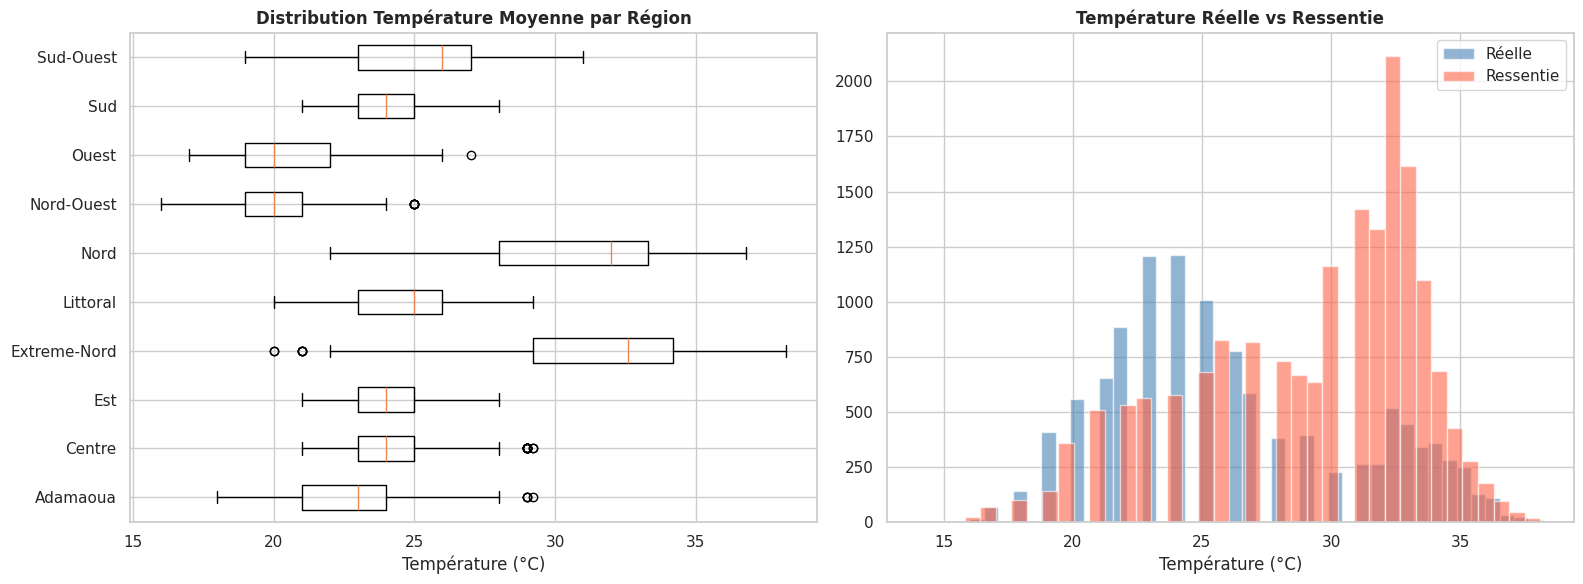

In [11]:
# ── 3.1 Distribution des températures par région ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot température moyenne par région
regions = sorted(df['region'].unique())
data_by_region = [df[df['region'] == r]['temperature_2m_mean'].dropna().values for r in regions]

axes[0].boxplot(data_by_region, labels=regions, vert=False)
axes[0].set_title('Distribution Température Moyenne par Région', fontweight='bold')
axes[0].set_xlabel('Température (°C)')

# Histogramme température ressentie vs réelle
axes[1].hist(df['temperature_2m_mean'].dropna(), bins=40, alpha=0.6, label='Réelle', color='steelblue')
axes[1].hist(df['apparent_temperature_mean'].dropna(), bins=40, alpha=0.6, label='Ressentie', color='tomato')
axes[1].set_title('Température Réelle vs Ressentie', fontweight='bold')
axes[1].set_xlabel('Température (°C)')
axes[1].legend()

plt.tight_layout()
plt.show()

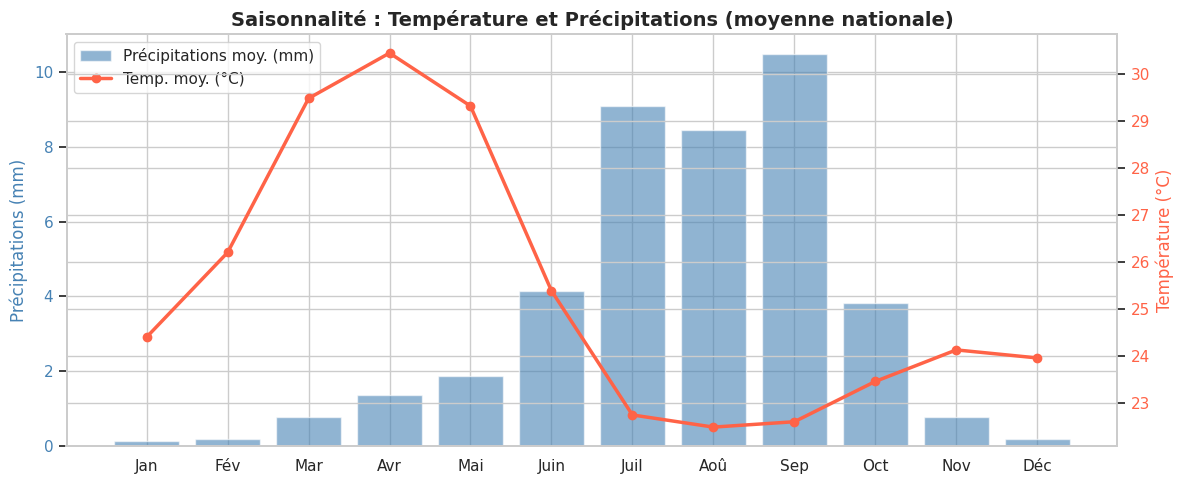

In [12]:
# ── 3.2 Saisonnalité — Températures moyennes mensuelles ─────────────────────
df['month'] = df['time'].dt.month
df['year']  = df['time'].dt.year
df['week']  = df['time'].dt.isocalendar().week.astype(int)

monthly_temp = df.groupby('month')['temperature_2m_mean'].mean()
monthly_rain = df.groupby('month')['precipitation_sum'].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
month_labels = ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Aoû','Sep','Oct','Nov','Déc']

ax1.bar(month_labels, monthly_rain.values, color='steelblue', alpha=0.6, label='Précipitations moy. (mm)')
ax1.set_ylabel('Précipitations (mm)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(month_labels, monthly_temp.values, color='tomato', marker='o', linewidth=2.5, label='Temp. moy. (°C)')
ax2.set_ylabel('Température (°C)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_title('Saisonnalité : Température et Précipitations (moyenne nationale)', fontweight='bold', fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

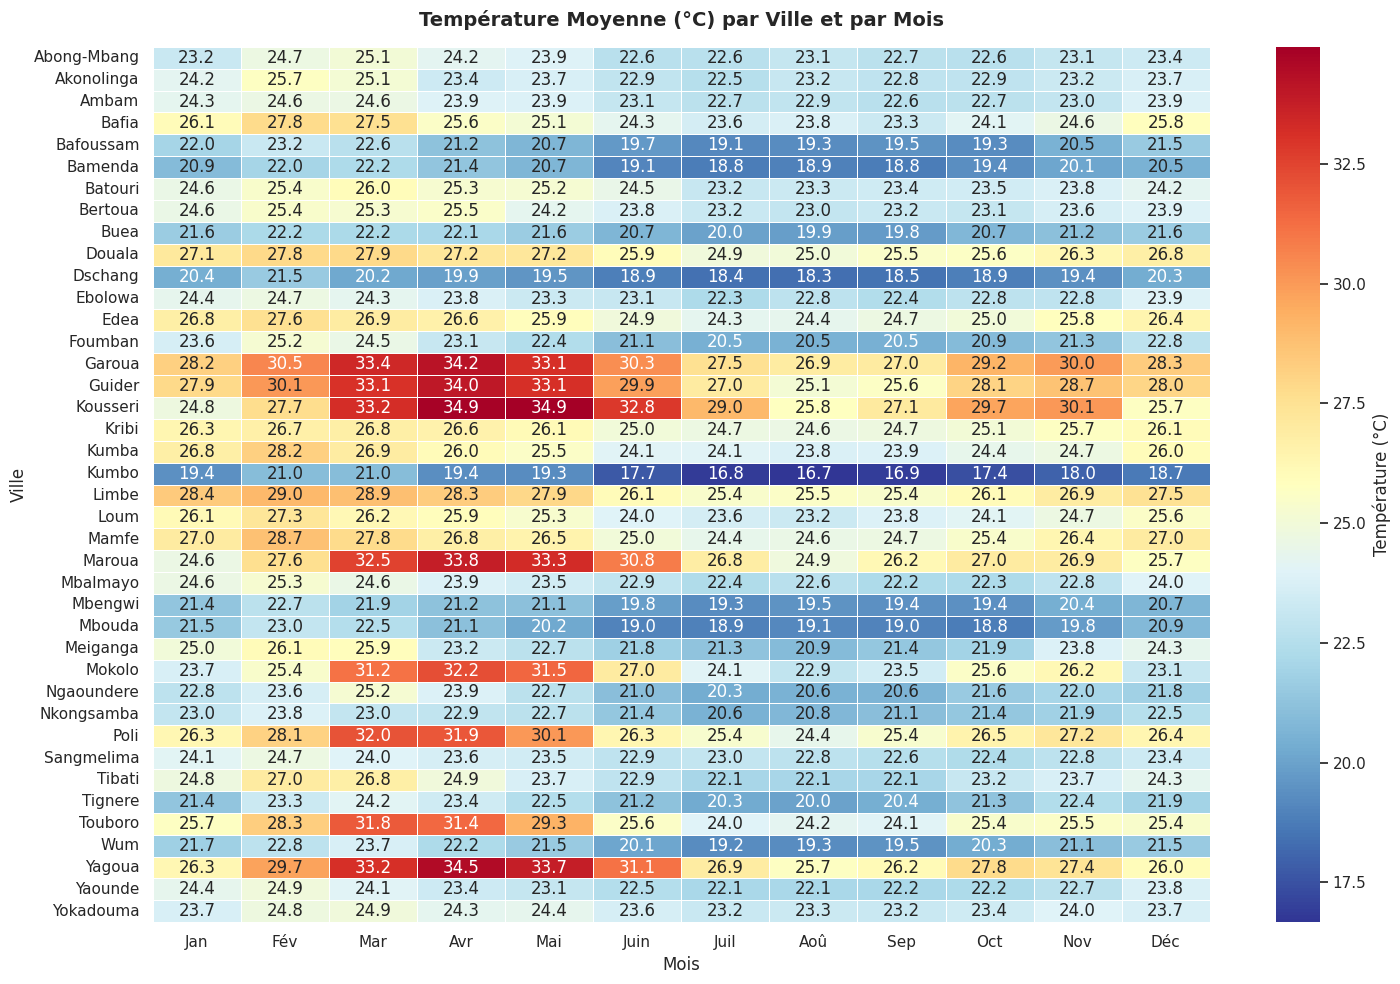

In [13]:
# ── 3.3 Carte de chaleur — Température par ville et mois ────────────────────
heatmap_data = df.groupby(['city', 'month'])['temperature_2m_mean'].mean().unstack()
heatmap_data.columns = ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Aoû','Sep','Oct','Nov','Déc']

plt.figure(figsize=(15, 10))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='RdYlBu_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Température (°C)'}
)
plt.title('Température Moyenne (°C) par Ville et par Mois', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Ville', fontsize=12)
plt.tight_layout()
plt.show()

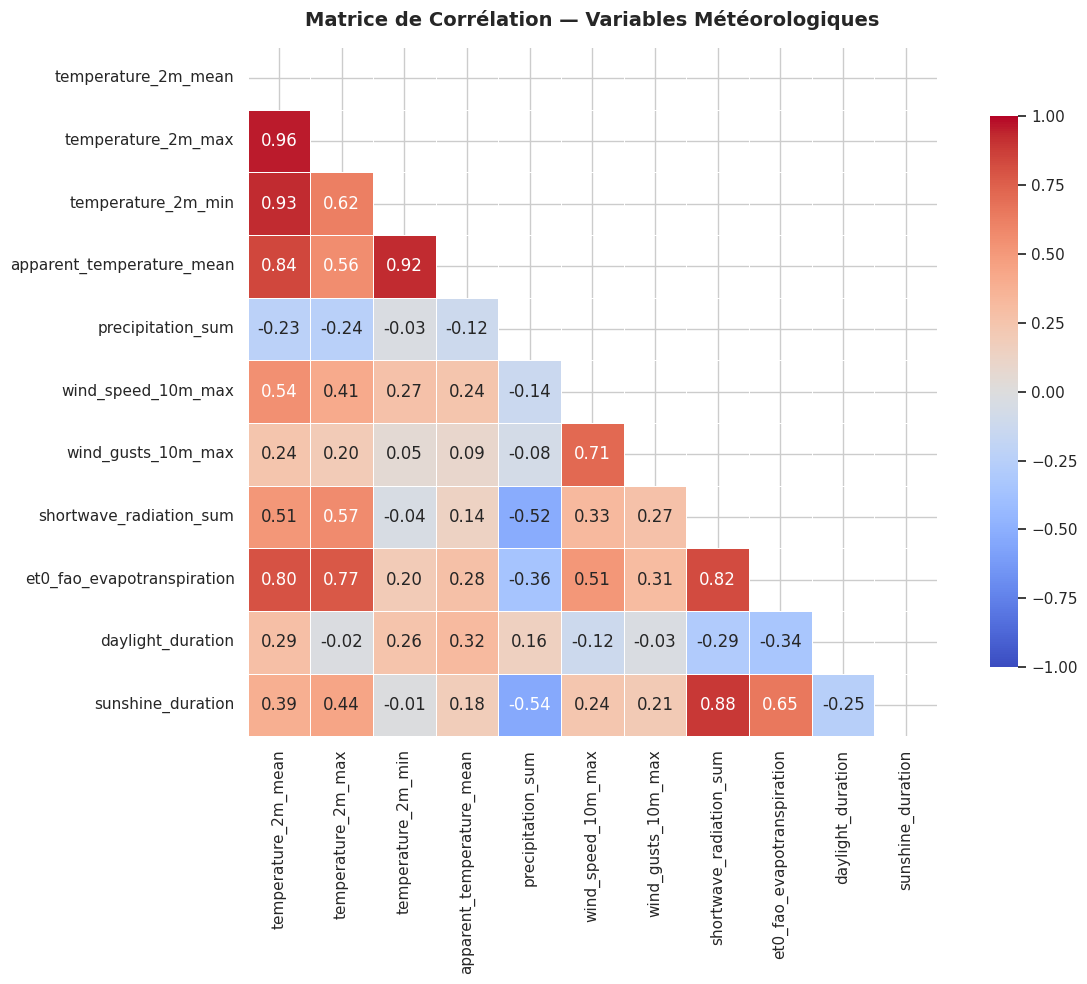

In [14]:
# ── 3.4 Matrice de corrélation ───────────────────────────────────────────────
corr_cols = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'apparent_temperature_mean', 'precipitation_sum', 'wind_speed_10m_max',
    'wind_gusts_10m_max', 'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'daylight_duration', 'sunshine_duration'
]

corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matrice de Corrélation — Variables Météorologiques', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [16]:
# ── 3.5 Carte géographique interactive (Plotly) ──────────────────────────────
city_stats = df.groupby(['city', 'region', 'latitude', 'longitude']).agg(
    temp_moy    = ('temperature_2m_mean', 'mean'),
    pluie_moy   = ('precipitation_sum', 'mean'),
    vent_max    = ('wind_speed_10m_max', 'mean'),
    radiation   = ('shortwave_radiation_sum', 'mean')
).reset_index().round(2)

fig = px.scatter_mapbox(
    city_stats,
    lat='latitude', lon='longitude',
    size='radiation',
    color='temp_moy',
    hover_name='city',
    hover_data={'region': True, 'pluie_moy': True, 'vent_max': True,
                'radiation': True, 'latitude': False, 'longitude': False},
    color_continuous_scale='RdYlBu_r',
    size_max=18,
    zoom=5,
    mapbox_style='open-street-map',
    title='📍 Carte des 42 Villes — Température & Rayonnement Solaire Moyens'
)
fig.update_layout(height=600, margin=dict(r=0, t=40, l=0, b=0))
fig.show()

In [17]:
# ── 3.6 Analyse de la direction des vents (rose des vents) ──────────────────
wind_bins = pd.cut(
    df['wind_direction_10m_dominant'],
    bins=np.arange(0, 380, 22.5),
    labels=[f"{int(a)}°" for a in np.arange(0, 360, 22.5)]
)

wind_counts = df.groupby(wind_bins)['wind_speed_10m_max'].mean().reset_index()
wind_counts.columns = ['direction', 'vitesse_moy']
wind_counts['angle'] = np.arange(0, 360, 22.5)

fig = go.Figure(go.Barpolar(
    r=wind_counts['vitesse_moy'].fillna(0),
    theta=wind_counts['angle'],
    width=22,
    marker=dict(color=wind_counts['vitesse_moy'].fillna(0), colorscale='Blues', showscale=True)
))
fig.update_layout(
    title='🌬️ Rose des Vents — Vitesse Moyenne par Direction',
    polar=dict(angularaxis=dict(direction='clockwise', rotation=90)),
    height=500
)
fig.show()

---
## 4. 🔧 Feature Engineering

> 💡 **Rappel du problème :** Nous n'avons pas de mesure directe de la qualité de l'air (PM2.5). Nous allons construire un **proxy** basé sur les conditions météorologiques connues pour favoriser la stagnation des polluants.

In [18]:
# ── 4.1 Variables temporelles ────────────────────────────────────────────────
df['day_of_year']   = df['time'].dt.dayofyear
df['day_of_week']   = df['time'].dt.dayofweek
df['quarter']       = df['time'].dt.quarter
df['is_dry_season'] = df['month'].isin([11, 12, 1, 2, 3]).astype(int)  # saison sèche

# Encodage cyclique (capture la périodicité)
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['doy_sin']    = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']    = np.cos(2 * np.pi * df['day_of_year'] / 365)

# ── 4.2 Variables météo dérivées ─────────────────────────────────────────────
df['temp_amplitude']       = df['temperature_2m_max'] - df['temperature_2m_min']
df['heat_stress_index']    = df['temperature_2m_mean'] * (1 + 0.01 * (df['et0_fao_evapotranspiration'].fillna(0)))
df['sunshine_ratio']       = df['sunshine_duration'] / (df['daylight_duration'] + 1e-6)
df['wind_x']               = df['wind_speed_10m_max'] * np.cos(np.radians(df['wind_direction_10m_dominant']))
df['wind_y']               = df['wind_speed_10m_max'] * np.sin(np.radians(df['wind_direction_10m_dominant']))
df['is_no_wind']           = (df['wind_speed_10m_max'] < 5).astype(int)  # stagnation de l'air
df['is_no_rain']           = (df['precipitation_sum'] < 0.1).astype(int)  # pas de lessivage

# ── 4.3 Construction du proxy PM2.5 ──────────────────────────────────────────
#
# Les conditions favorisant la pollution de l'air :
#   + Température élevée       → favorise les réactions photochimiques
#   + Faible vent              → stagnation des particules
#   + Absence de pluie         → pas d'effet de lessivage
#   + Fort ensoleillement      → ozone et particules secondaires
#   + Saison sèche             → poussières, feux de brousse
#
# ⚠️ IMPORTANT : Ce proxy est une approximation heuristique à des fins
# de démonstration. Les participants sont invités à l'améliorer ou à
# le remplacer par une approche plus rigoureuse.

scaler_tmp = StandardScaler()
proxy_features = ['temperature_2m_mean', 'shortwave_radiation_sum', 'et0_fao_evapotranspiration']
df_proxy = df[proxy_features].fillna(df[proxy_features].mean())

df['pm25_proxy'] = (
    0.40 * df_proxy['temperature_2m_mean']
    + 0.30 * df_proxy['shortwave_radiation_sum']
    + 0.30 * df_proxy['et0_fao_evapotranspiration']
    + 8.0  * df['is_no_wind']
    + 5.0  * df['is_no_rain']
    + 4.0  * df['is_dry_season']
    + np.random.normal(0, 2, len(df))  # bruit pour simuler variabilité
).clip(lower=0)

print("✅ Features construites !")
print(f"\nProxy PM2.5 — statistiques :")
print(df['pm25_proxy'].describe().round(2))

✅ Features construites !

Proxy PM2.5 — statistiques :
count    87240.00
mean        20.54
std          5.23
min          5.71
25%         16.47
50%         19.39
75%         24.93
max         37.72
Name: pm25_proxy, dtype: float64


In [19]:
# ── 4.4 Variables lag (séries temporelles) ───────────────────────────────────
# Tri par ville et date pour les décalages temporels
df = df.sort_values(['city', 'time']).reset_index(drop=True)

for lag in [1, 3, 7]:
    df[f'temp_lag{lag}']  = df.groupby('city')['temperature_2m_mean'].shift(lag)
    df[f'rain_lag{lag}']  = df.groupby('city')['precipitation_sum'].shift(lag)
    df[f'proxy_lag{lag}'] = df.groupby('city')['pm25_proxy'].shift(lag)

# Rolling means (moyenne glissante 7 jours)
df['temp_roll7']  = df.groupby('city')['temperature_2m_mean'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['wind_roll7']  = df.groupby('city')['wind_speed_10m_max'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['proxy_roll7'] = df.groupby('city')['pm25_proxy'].transform(lambda x: x.rolling(7, min_periods=1).mean())

print("✅ Variables de lag et de fenêtre glissante ajoutées.")
print(f"   Nouvelles colonnes : {[c for c in df.columns if 'lag' in c or 'roll' in c]}")

✅ Variables de lag et de fenêtre glissante ajoutées.
   Nouvelles colonnes : ['temp_lag1', 'rain_lag1', 'proxy_lag1', 'temp_lag3', 'rain_lag3', 'proxy_lag3', 'temp_lag7', 'rain_lag7', 'proxy_lag7', 'temp_roll7', 'wind_roll7', 'proxy_roll7']


In [20]:
# ── 4.5 Encodage des variables catégorielles ─────────────────────────────────
# Encodage ordinal des régions (pour modèles non-arbres, préférer le One-Hot)
le_region = LabelEncoder()
df['region_enc'] = le_region.fit_transform(df['region'])

le_city = LabelEncoder()
df['city_enc'] = le_city.fit_transform(df['city'])

print("✅ Encodage effectué.")
print(df[['city', 'city_enc', 'region', 'region_enc']].drop_duplicates().head(10))

✅ Encodage effectué.
              city  city_enc      region  region_enc
0      Abong-Mbang         0         Est           2
2181    Akonolinga         1      Centre           1
4362         Ambam         2         Sud           8
6543         Bafia         3      Centre           1
8724     Bafoussam         4       Ouest           7
10905      Bamenda         5  Nord-Ouest           6
13086      Batouri         6         Est           2
15267      Bertoua         7         Est           2
17448         Buea         8   Sud-Ouest           9
19629       Douala         9    Littoral           4


---
## 5. 🤖 Modélisation — Baseline

> **Objectif :** Prédire `pm25_proxy` — un index composite de risque de pollution atmosphérique — à partir des variables météorologiques.

In [21]:
# ── 5.1 Sélection des features ───────────────────────────────────────────────
FEATURES = [
    # Météo directe
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_mean', 'precipitation_sum', 'rain_sum',
    'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_direction_10m_dominant',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'sunshine_duration', 'daylight_duration', 'precipitation_hours',
    # Features construites
    'temp_amplitude', 'sunshine_ratio', 'wind_x', 'wind_y',
    'is_no_wind', 'is_no_rain', 'is_dry_season',
    'heat_stress_index',
    # Temporelles
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'quarter', 'day_of_week',
    # Lags
    'temp_lag1', 'temp_lag3', 'temp_lag7',
    'rain_lag1', 'rain_lag7',
    'proxy_lag1', 'proxy_lag3',
    'temp_roll7', 'wind_roll7', 'proxy_roll7',
    # Géographie
    'latitude', 'longitude', 'region_enc', 'city_enc'
]

TARGET = 'pm25_proxy'

df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

print(f"📐 Jeu de données final pour la modélisation : {X.shape}")
print(f"   Target — mean: {y.mean():.2f} | std: {y.std():.2f} | min: {y.min():.2f} | max: {y.max():.2f}")

📐 Jeu de données final pour la modélisation : (2, 42)
   Target — mean: 25.68 | std: 0.62 | min: 25.24 | max: 26.12


In [22]:
# ── 5.2 Split Train / Test (respect de la temporalité) ───────────────────────
# ⚠️ Pour les séries temporelles, NE PAS utiliser un split aléatoire !
# On garde les 80% premières observations pour l'entraînement.

split_idx = int(len(df_model) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train : {X_train.shape[0]:,} obs | Test : {X_test.shape[0]:,} obs")

Train : 1 obs | Test : 1 obs


In [23]:
# ── 5.3 Entraînement de plusieurs modèles ────────────────────────────────────
models = {
    'Linear Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=SEED))
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED))
    ]),
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = {
        'MAE'  : mean_absolute_error(y_test, y_pred),
        'RMSE' : np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²'   : r2_score(y_test, y_pred),
        'y_pred': y_pred
    }
    print(f"  {name:<25} | MAE={results[name]['MAE']:.3f} | RMSE={results[name]['RMSE']:.3f} | R²={results[name]['R²']:.3f}")

  Linear Regression         | MAE=0.883 | RMSE=0.883 | R²=nan
  Ridge                     | MAE=0.883 | RMSE=0.883 | R²=nan
  Random Forest             | MAE=0.883 | RMSE=0.883 | R²=nan
  Gradient Boosting         | MAE=0.883 | RMSE=0.883 | R²=nan


In [29]:
# Diagnostic R² NaN
import pandas as pd, numpy as np
from sklearn.metrics import r2_score

print("=== Diagnostic R² NaN ===")
print(f"y_test  — NaN: {np.isnan(y_test).sum()}, Inf: {np.isinf(y_test).sum()}, std: {y_test.std():.6f}")
print(f"y_pred  — NaN: {np.isnan(y_pred).sum()}, Inf: {np.isinf(y_pred).sum()}")
print(f"Nombre observations test: {len(y_test)}")
print(f"y_test unique values: {y_test.nunique()}")
print(f"r2_score direct: {r2_score(y_test, y_pred)}")


=== Diagnostic R² NaN ===
y_test  — NaN: 0, Inf: 0, std: nan
y_pred  — NaN: 0, Inf: 0
Nombre observations test: 1
y_test unique values: 1
r2_score direct: nan


In [28]:
# Vérifie la taille de df_model et les NaN par colonne
print(f"df_model shape: {df_model.shape}")
print(f"\nNaN par feature (avant dropna) :")
missing_features = df[FEATURES + [TARGET]].isnull().sum()
print(missing_features[missing_features > 0].sort_values(ascending=False))


df_model shape: (2, 43)

NaN par feature (avant dropna) :
temp_amplitude                82475
wind_x                        77862
wind_speed_10m_max            77862
wind_y                        77862
temp_lag7                     75763
temp_lag3                     75741
temp_lag1                     75735
temperature_2m_mean           75732
heat_stress_index             75732
temperature_2m_min            75235
apparent_temperature_mean     69563
temperature_2m_max            53906
wind_gusts_10m_max            45573
wind_roll7                    39775
rain_lag7                     39732
temp_roll7                    39663
rain_lag1                     39510
precipitation_sum             39471
rain_sum                      39471
longitude                     23991
shortwave_radiation_sum       17342
et0_fao_evapotranspiration    17119
latitude                      13086
sunshine_duration               489
sunshine_ratio                  489
proxy_lag3                      120
proxy_

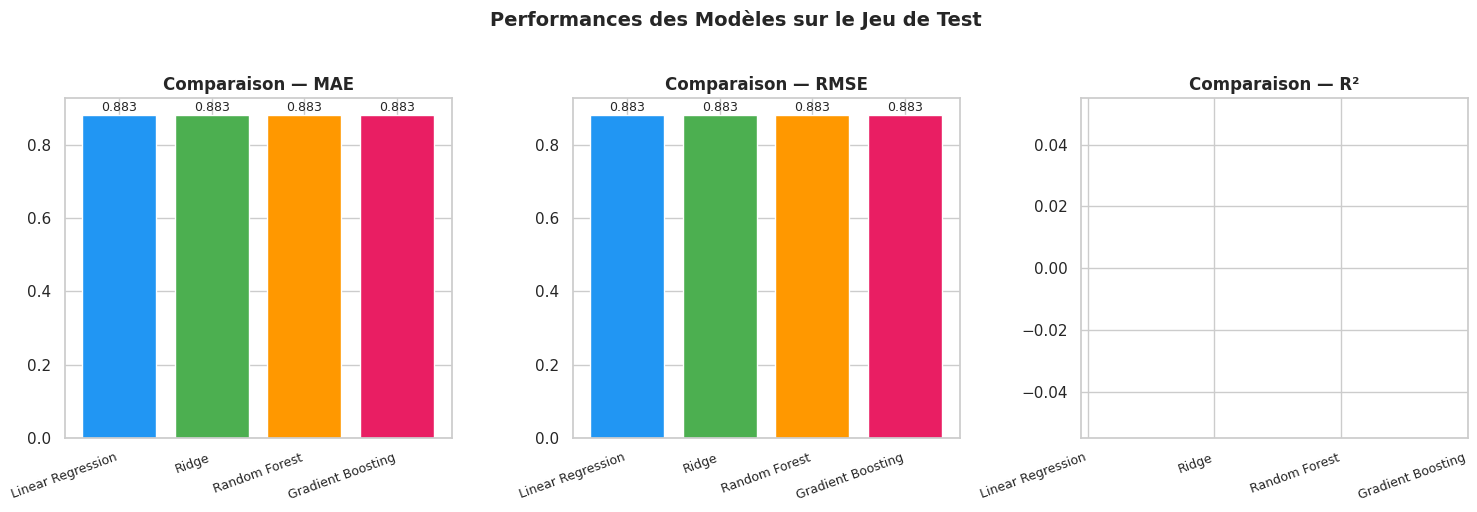

In [30]:
# ── 5.4 Visualisation des performances ───────────────────────────────────────
results_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'y_pred'}
                           for k, v in results.items()}).T.reset_index()
results_df.columns = ['Modèle', 'MAE', 'RMSE', 'R²']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.bar(results_df['Modèle'], results_df[metric].astype(float), color=colors)
    ax.set_title(f'Comparaison — {metric}', fontweight='bold')
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['Modèle'], rotation=20, ha='right', fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.suptitle('Performances des Modèles sur le Jeu de Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

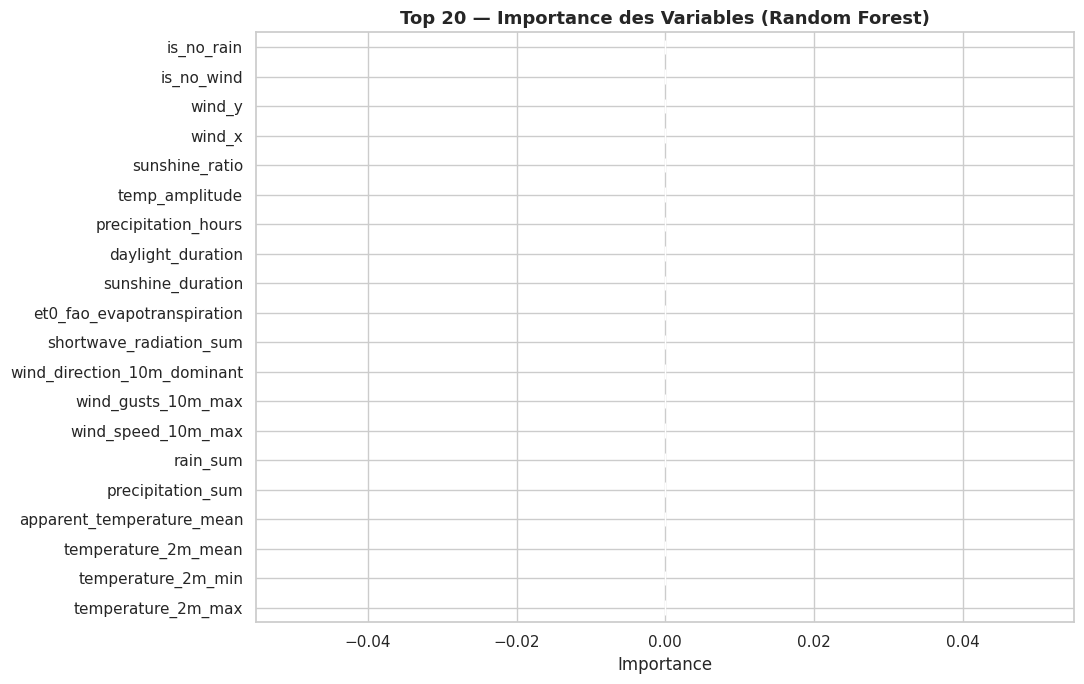

In [25]:
# ── 5.5 Importance des variables (Random Forest) ─────────────────────────────
rf_model    = models['Random Forest'].named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
top20       = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(11, 7))
top20.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 — Importance des Variables (Random Forest)', fontweight='bold', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

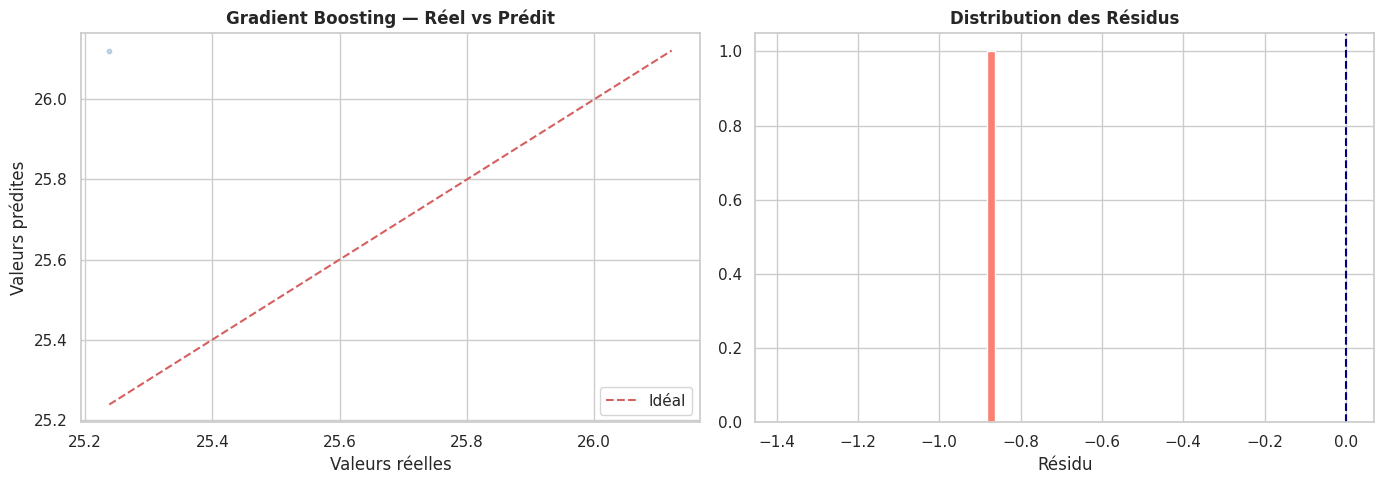


📊 Gradient Boosting — Performances finales :
   R²   = nan
   MAE  = 0.8834
   RMSE = 0.8834


In [26]:
# ── 5.6 Prédictions vs Réalité ───────────────────────────────────────────────
best_model = 'Gradient Boosting'
y_pred_best = results[best_model]['y_pred']

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test[:500], y_pred_best[:500], alpha=0.3, s=10, color='steelblue')
lim = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Idéal')
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title(f'{best_model} — Réel vs Prédit', fontweight='bold')
axes[0].legend()

# Résidus
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white')
axes[1].axvline(0, color='navy', linewidth=1.5, linestyle='--')
axes[1].set_title('Distribution des Résidus', fontweight='bold')
axes[1].set_xlabel('Résidu')

plt.tight_layout()
plt.show()

print(f"\n📊 {best_model} — Performances finales :")
print(f"   R²   = {results[best_model]['R²']:.4f}")
print(f"   MAE  = {results[best_model]['MAE']:.4f}")
print(f"   RMSE = {results[best_model]['RMSE']:.4f}")

---
## 6. 🚀 Pistes Avancées

### 6.1 Amélioration du modèle

```python
# Option A — XGBoost / LightGBM
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Option B — Modèles de séries temporelles
# Prophet (Meta), SARIMA, LSTM, Temporal Fusion Transformer
from prophet import Prophet

# Option C — Validation temporelle rigoureuse
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model, X, y, cv=tscv, scoring='r2')

# Option D — Optimisation des hyperparamètres
from sklearn.model_selection import RandomizedSearchCV
# ou optuna pour des recherches plus efficaces
```

### 6.2 Dashboard interactif (Streamlit)

```python
# app.py
import streamlit as st
import plotly.express as px

st.title('🌍 Qualité de l\'Air au Cameroun — Tableau de Bord')

# Sélecteur de ville
ville = st.selectbox('Choisir une ville', df['city'].unique())
region = st.selectbox('Filtrer par région', ['Toutes'] + list(df['region'].unique()))

# Afficher la carte de chaleur
fig = px.choropleth(...)
st.plotly_chart(fig)

# Zone d'alerte
risk_score = model.predict([[...]])[0]
if risk_score > seuil_rouge:
    st.error('🔴 ALERTE : Risque élevé de pollution')
elif risk_score > seuil_orange:
    st.warning('🟠 ATTENTION : Qualité de l\'air dégradée')
else:
    st.success('🟢 Qualité de l\'air satisfaisante')

# Lancer avec : streamlit run app.py
```

### 6.3 Pistes d'enrichissement des données

- **NASA FIRMS** : données des feux de forêt (disponibles gratuitement)
- **Open-Meteo / ERA5** : données horaires supplémentaires
- **WHO / OMS** : valeurs guides de qualité de l'air
- **Données épidémiologiques** : hospitalisations respiratoires (si disponibles)

### 6.4 Pour les points bonus

```python
# API FastAPI — exposer votre modèle
from fastapi import FastAPI
import joblib

app = FastAPI()
model = joblib.load('model.pkl')

@app.post('/predict')
def predict(data: dict):
    features = [data[f] for f in FEATURES]
    prediction = model.predict([features])[0]
    return {'pm25_proxy': round(prediction, 2), 'risk_level': classify_risk(prediction)}
```